# Lab 1: Neural Models — Learning, Depth, Activations, and Output Layers

## Task 1: Understand the Problem

### Problem Specification

We have two binary sensor inputs, x1 and x2. The device should raise a
sensor-disagreement warning exactly when one sensor is active and the
other is inactive.

The required decision rule is XOR.

| x1 | x2 | Warning (y) |
|----|----|-------------|
| 0  | 0  | 0           |
| 0  | 1  | 1           |
| 1  | 0  | 1           |
| 1  | 1  | 0           |

Input space:
X = {(0,0), (0,1), (1,0), (1,1)}

Output space:
Y = {0,1}

### Why XOR is not linearly separable

The Class 1 points are (0,1) and (1,0), while the Class 0 points are
(0,0) and (1,1). Since the two classes occur at opposite corners of
the square, no single straight decision boundary can separate the two
classes.

Therefore, XOR cannot be solved perfectly using a linear decision
boundary.

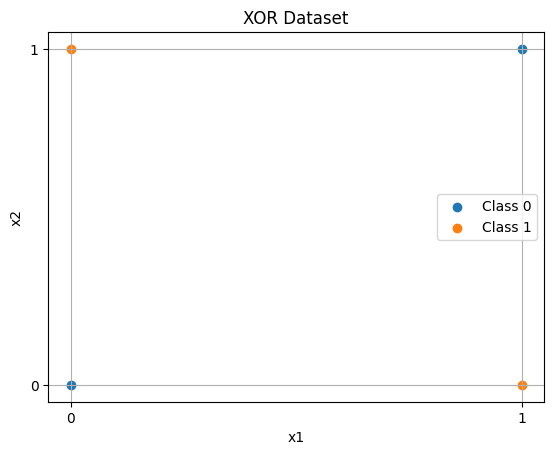

In [1]:
import matplotlib.pyplot as plt

X = [(0, 0), (0, 1), (1, 0), (1, 1)]
y = [0, 1, 1, 0]

for label in [0, 1]:
    points = [X[i] for i in range(len(X)) if y[i] == label]

    plt.scatter(
        [point[0] for point in points],
        [point[1] for point in points],
        label=f"Class {label}"
    )

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR Dataset")
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.grid(True)
plt.legend()
plt.show()

### Prediction for a Single Affine Layer + Sigmoid

If we use only a single affine transformation followed by a sigmoid
output, the model will not be able to perfectly learn XOR.

The affine transformation produces a linear decision boundary. The
sigmoid converts its output into a probability, but it does not make
the decision boundary non-linear. Since XOR is not linearly separable,
the model should fail to classify all four examples correctly.

## Task 2: Design the Intelligent Agent

### Model Architecture

The baseline neural network has the architecture:

2 inputs → 2 hidden units → 1 output

The hidden layer uses a nonlinear sigmoid activation. The output layer
uses a sigmoid activation because the task is binary classification.

The model is trained using binary cross-entropy loss and a
gradient-based optimisation method.

### 1. Why is the hidden nonlinearity scientifically necessary?

XOR cannot be separated using a single linear decision boundary.
Adding a hidden layer alone is not sufficient because multiple affine
layers still combine into an affine transformation. The nonlinear
activation in the hidden layer allows the network to learn a
nonlinear representation of the inputs and therefore represent the
XOR decision rule.

### 2. Why sigmoid + binary cross-entropy?

The output is a binary yes/no decision, so a sigmoid output converts
the model's output into a value between 0 and 1 that can be interpreted
as the probability of class 1.

Binary cross-entropy is suitable for comparing these predicted
probabilities with the binary target labels.

### 3. Validation Criteria

We will consider the model to have learned the XOR task if:

1. The final loss decreases substantially compared with the initial loss.
2. The four final predicted probabilities correspond to the XOR labels.
3. All four examples are classified correctly after thresholding the
   probabilities at 0.5.
4. The gradients of the model parameters are nonzero during training,
   showing that backpropagation is providing a learning signal.

## Task 3: Use an LLM to Generate a First Implementation

### LLM Prompt

I asked an LLM to generate a minimal PyTorch implementation of the
neural network designed in Task 2.

The prompt used was:

"Generate minimal PyTorch code for the following model and dataset.

Dataset:
XOR training examples:
(0,0) → 0
(0,1) → 1
(1,0) → 1
(1,1) → 0

Requirements:
- Use a 2 → 2 → 1 neural network.
- Use a sigmoid activation in the hidden layer.
- Use a sigmoid binary output.
- Use binary cross-entropy loss, or BCEWithLogitsLoss if using logits.
- Use random weight initialization.
- Use full-batch training.
- Train for a few thousand lightweight CPU steps.
- Set a random seed for reproducibility.
- Print the initial and final loss.
- After training, report the final probability for all four inputs.
- Print the thresholded predictions.
- After backward(), expose at least one parameter gradient tensor.
- Keep the implementation minimal and do not change the architecture
  or dataset."

### Generated Implementation

The following implementation was generated from the prompt above and
then inspected before execution.

In [2]:
import torch
import torch.nn as nn

torch.manual_seed(42)

X = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y = torch.tensor([
    [0.0],
    [1.0],
    [1.0],
    [0.0]
])

model = nn.Sequential(
    nn.Linear(2, 2),
    nn.Sigmoid(),
    nn.Linear(2, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1.0)

with torch.no_grad():
    initial_loss = criterion(model(X), y).item()

for step in range(5000):
    logits = model(X)
    loss = criterion(logits, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    logits = model(X)
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= 0.5).float()

print("Initial loss:", initial_loss)
print("Final loss:", loss.item())

print("\nFinal probabilities:")
print(probabilities)

print("\nPredicted labels:")
print(predictions)

print("\nGradient of first-layer weights:")
print(model[0].weight.grad)

Initial loss: 0.7482295036315918
Final loss: 0.002629873575642705

Final probabilities:
tensor([[0.0033],
        [0.9976],
        [0.9976],
        [0.0024]])

Predicted labels:
tensor([[0.],
        [1.],
        [1.],
        [0.]])

Gradient of first-layer weights:
tensor([[-0.0001, -0.0001],
        [-0.0001, -0.0001]])


### Changes / Corrections to the Generated Implementation

The generated implementation was checked against the laboratory
requirements. Two implementation decisions were made:

1. **BCEWithLogitsLoss was used with raw output logits.**
   Instead of explicitly applying a sigmoid before the loss, the
   implementation uses `BCEWithLogitsLoss`, which combines the sigmoid
   operation and binary cross-entropy internally.

2. **The sigmoid is applied only when reporting probabilities.**
   During training, the model output remains as logits for
   `BCEWithLogitsLoss`. After training, `torch.sigmoid(logits)` is used
   to convert the final logits into probabilities for interpretation
   and threshold-based predictions.

These changes preserve the required 2 → 2 → 1 architecture and the
binary XOR task while using the numerically stable logits-based loss
specified in the laboratory worksheet.

### Task 4A: Basic Learning Check

The initial loss was 0.7482, while the final loss decreased to
approximately 0.00263. This substantial decrease indicates that the
model learned to reduce its prediction error.

The final probabilities were approximately:

| Input | True Label | Probability | Predicted Label |
|-------|------------|-------------|-----------------|
| (0,0) | 0 | 0.0033 | 0 |
| (0,1) | 1 | 0.9976 | 1 |
| (1,0) | 1 | 0.9976 | 1 |
| (1,1) | 0 | 0.0024 | 0 |

All four XOR examples were classified correctly, giving an accuracy
of 4/4.

A first-layer gradient tensor was also nonzero after backpropagation,
showing that gradients were being computed for the model parameters.


In [3]:
# Recreate the model so we can inspect an early-training gradient
torch.manual_seed(42)

model_early = nn.Sequential(
    nn.Linear(2, 2),
    nn.Sigmoid(),
    nn.Linear(2, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_early.parameters(), lr=1.0)

logits = model_early(X)
loss = criterion(logits, y)
optimizer.zero_grad()
loss.backward()

print("Loss before training:", loss.item())
print("\nFirst-layer weight gradient:")
print(model_early[0].weight.grad)

print("\nGradient norm:")
print(torch.norm(model_early[0].weight.grad).item())

Loss before training: 0.7482295036315918

First-layer weight gradient:
tensor([[-0.0040, -0.0044],
        [ 0.0064,  0.0081]])

Gradient norm:
0.0118937436491251


### Task 4B: Backpropagation Check

Before training, the loss was approximately 0.7482.

After calling `loss.backward()`, the gradient of the first-layer
weights was:

\[
\frac{\partial L}{\partial W^{(1)}} =
\begin{bmatrix}
-0.0040 & -0.0044 \\
0.0064 & 0.0081
\end{bmatrix}
\]

The gradient norm was approximately 0.01189, which is nonzero.

This confirms that backpropagation computed a learning signal for the
first-layer weights. The gradient indicates how the loss changes with
respect to each first-layer weight, and the optimizer can use these
values to update the weights.

Because the loss was computed over all four training examples, the
gradient represents the combined contribution of the examples to the
loss gradient.

In [4]:
# Task 4C: Symmetry experiment
torch.manual_seed(42)

model_sym = nn.Sequential(
    nn.Linear(2, 2),
    nn.Sigmoid(),
    nn.Linear(2, 1)
)

with torch.no_grad():
    model_sym[0].weight.zero_()
    model_sym[0].bias.zero_()
    model_sym[2].weight.zero_()
    model_sym[2].bias.zero_()

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_sym.parameters(), lr=1.0)

print("Initial hidden-layer weights:")
print(model_sym[0].weight)

for step in range(5):
    logits = model_sym(X)
    loss = criterion(logits, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"\nAfter step {step + 1}:")
    print(model_sym[0].weight)

Initial hidden-layer weights:
Parameter containing:
tensor([[0., 0.],
        [0., 0.]], requires_grad=True)

After step 1:
Parameter containing:
tensor([[0., 0.],
        [0., 0.]], requires_grad=True)

After step 2:
Parameter containing:
tensor([[0., 0.],
        [0., 0.]], requires_grad=True)

After step 3:
Parameter containing:
tensor([[0., 0.],
        [0., 0.]], requires_grad=True)

After step 4:
Parameter containing:
tensor([[0., 0.],
        [0., 0.]], requires_grad=True)

After step 5:
Parameter containing:
tensor([[0., 0.],
        [0., 0.]], requires_grad=True)


### Task 4C: Symmetry from Zero Initialization

All weights and biases were initialized to zero. The hidden-layer weight
matrix remained:

\[
\begin{bmatrix}
0 & 0\\
0 & 0
\end{bmatrix}
\]

through all five training steps.

The two hidden neurons therefore remained identical and did not develop
different features. Since they started with identical parameters, they
receive the same gradient and therefore the same parameter updates.

In this particular experiment, the output-layer weights were also
initialized to zero. This causes the gradient reaching the hidden layer
to be zero initially, so the hidden-layer weights remain exactly zero.

This demonstrates why identical zero initialization is unsuitable for
learning distinct hidden representations. Random initialization breaks
this symmetry so that different hidden units can receive different
updates and learn different features.

In [5]:
# Task 4D: Compare hidden-layer activation functions

def run_activation_experiment(activation_name):
    torch.manual_seed(42)

    if activation_name == "sigmoid":
        activation = nn.Sigmoid()
    elif activation_name == "tanh":
        activation = nn.Tanh()
    elif activation_name == "relu":
        activation = nn.ReLU()

    model = nn.Sequential(
        nn.Linear(2, 2),
        activation,
        nn.Linear(2, 1)
    )

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=1.0)

    # Early gradient
    logits = model(X)
    loss = criterion(logits, y)

    optimizer.zero_grad()
    loss.backward()

    early_gradient_norm = torch.norm(model[0].weight.grad).item()

    # Train
    for step in range(5000):
        logits = model(X)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Final predictions
    with torch.no_grad():
        probabilities = torch.sigmoid(model(X))
        predictions = (probabilities >= 0.5).float()

    correct = int((predictions == y).sum().item())

    return loss.item(), correct, early_gradient_norm


for activation in ["sigmoid", "tanh", "relu"]:
    final_loss, correct, gradient_norm = run_activation_experiment(activation)

    print(f"{activation.capitalize()}:")
    print(f"  Final loss = {final_loss:.6f}")
    print(f"  Correct = {correct}/4")
    print(f"  Early gradient norm = {gradient_norm:.6f}")
    print()

Sigmoid:
  Final loss = 0.002630
  Correct = 4/4
  Early gradient norm = 0.011894

Tanh:
  Final loss = 0.000637
  Correct = 4/4
  Early gradient norm = 0.028684

Relu:
  Final loss = 0.346600
  Correct = 3/4
  Early gradient norm = 0.082002



### Task 4D: Activation Function Experiment

The hidden activation was changed while keeping the network architecture,
dataset, loss function, optimizer, learning rate, and number of training
steps unchanged.

| Hidden activation | Final loss | Correct | Early gradient norm |
|-------------------|------------|---------|---------------------|
| Sigmoid           | 0.002630   | 4/4     | 0.011894            |
| Tanh              | 0.000637   | 4/4     | 0.028684            |
| ReLU              | 0.346600   | 3/4     | 0.082002            |

Both sigmoid and tanh successfully classified all four XOR examples.
Tanh achieved the lowest final loss in this particular run.

ReLU had the largest early first-layer gradient norm, but it did not
achieve perfect classification in this run. This shows that a larger
initial gradient does not by itself guarantee better final performance.

The results demonstrate that the choice of hidden activation can affect
both the gradient signal and the learning outcome.

## Task 5: Three-Class Extension

The binary XOR problem is extended to three classes:

- Class 0: (0,0)
- Class 1: disagreement, i.e. (0,1) and (1,0)
- Class 2: (1,1)

The hidden representation is kept small, but the single binary output
is replaced with three output logits.

The model therefore has the architecture:

2 inputs → 2 hidden units → 3 logits

For multiclass classification, CrossEntropyLoss is used. The model
outputs raw logits, and the loss internally handles the conversion to
class probabilities.

In [6]:
# Task 5: Three-class classification

torch.manual_seed(42)

X_3class = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y_3class = torch.tensor([0, 1, 1, 2])

model_3class = nn.Sequential(
    nn.Linear(2, 2),
    nn.Tanh(),
    nn.Linear(2, 3)
)

criterion_3class = nn.CrossEntropyLoss()
optimizer_3class = torch.optim.SGD(
    model_3class.parameters(),
    lr=1.0
)

# Train
for step in range(5000):
    logits = model_3class(X_3class)
    loss = criterion_3class(logits, y_3class)

    optimizer_3class.zero_grad()
    loss.backward()
    optimizer_3class.step()

# Final predictions
with torch.no_grad():
    logits = model_3class(X_3class)
    probabilities = torch.softmax(logits, dim=1)
    predictions = torch.argmax(probabilities, dim=1)

print("Final loss:", loss.item())

print("\nFinal logits:")
print(logits)

print("\nFinal probabilities:")
print(probabilities)

print("\nPredicted classes:")
print(predictions)

print("\nTrue classes:")
print(y_3class)

print("\nProbability sums:")
print(probabilities.sum(dim=1))

Final loss: 0.0002455401117913425

Final logits:
tensor([[  9.4181,   1.2406, -10.5668],
        [ -2.8013,   6.7260,  -2.2137],
        [ -2.8013,   6.7260,  -2.2137],
        [ -7.2236,   0.4837,   8.6185]])

Final probabilities:
tensor([[9.9972e-01, 2.8085e-04, 2.0919e-09],
        [7.2823e-05, 9.9980e-01, 1.3105e-04],
        [7.2823e-05, 9.9980e-01, 1.3105e-04],
        [1.3174e-07, 2.9306e-04, 9.9971e-01]])

Predicted classes:
tensor([0, 1, 1, 2])

True classes:
tensor([0, 1, 1, 2])

Probability sums:
tensor([1.0000, 1.0000, 1.0000, 1.0000])


### Task 5: Three-Class Classification Results

The binary XOR problem was extended to three classes:

- Class 0: (0,0)
- Class 1: disagreement, i.e. (0,1) and (1,0)
- Class 2: (1,1)

The final model used the architecture:

2 inputs → 2 hidden units → 3 logits

CrossEntropyLoss was used for multiclass classification.

The final loss was approximately 0.000246.

The final predictions were:

Predicted classes: [0, 1, 1, 2]
True classes:      [0, 1, 1, 2]

Therefore, all four training examples were classified correctly.

The final logits were:

| Input | Logit 0 | Logit 1 | Logit 2 |
|-------|---------|---------|---------|
| (0,0) | 9.4181 | 1.2406 | -10.5668 |
| (0,1) | -2.8013 | 6.7260 | -2.2137 |
| (1,0) | -2.8013 | 6.7260 | -2.2137 |
| (1,1) | -7.2236 | 0.4837 | 8.6185 |

Softmax converted these logits into probabilities. For every input,
the three probabilities summed to approximately 1.0000, as expected.

The model assigns the highest probability to the correct class for
all four examples.

### Why is the logit gradient p - y?

For multiclass classification with softmax probabilities and
cross-entropy loss, the gradient of the loss with respect to each
logit has the form:

∂L/∂z_i = p_i - y_i

where p_i is the predicted probability for class i and y_i is the
one-hot target for class i.

For the correct class, y_i = 1. If its predicted probability is less
than 1, then p_i - y_i is negative, causing gradient descent to increase
the corresponding logit.

For an incorrect class, y_i = 0, so the gradient is p_i, which is
positive. Gradient descent therefore decreases the corresponding
logit.

Thus, the gradient provides a direct learning signal: increase the
logit of the correct class and decrease the logits of incorrect
classes.

## Reflection Questions

### Reflection 1: Depth vs. Nonlinearity

Depth means stacking multiple layers in a neural network. However, if
every layer is only an affine transformation, multiple layers can be
combined into a single affine transformation.

Therefore, depth alone does not allow the network to represent a
nonlinear function such as XOR. A nonlinear activation function between
layers is required so that the network can learn a nonlinear
representation and decision boundary.

### Reflection 2: Evidence of Learning

Several observations provided evidence that the binary XOR model learned
the task.

First, the loss decreased substantially from 0.7482 initially to
approximately 0.00263 after training.

Second, the final probabilities were approximately:

(0,0) → 0.0033
(0,1) → 0.9976
(1,0) → 0.9976
(1,1) → 0.0024

Using a threshold of 0.5 produced the predictions [0, 1, 1, 0],
which correctly classified all four examples.

Finally, the early first-layer gradient norm was 0.01189, which was
nonzero. This showed that backpropagation produced a learning signal
for the model parameters.

### Reflection 3: Initialization and Symmetry

When hidden units start with identical parameters, they produce the same
outputs and receive the same gradients. Therefore, they receive the
same updates and remain identical instead of learning different
representations.

In our zero-initialization experiment, both the hidden-layer and
output-layer parameters were initialized to zero. The hidden-layer
weights therefore remained exactly zero throughout the five observed
training steps.

Random initialization breaks this symmetry, allowing different hidden
units to receive different updates and potentially learn different
features.

### Reflection 4: Activation Functions

The hidden activation affected both the gradient signal and the final
learning result.

| Activation | Final Loss | Correct | Early Gradient Norm |
|------------|------------|---------|---------------------|
| Sigmoid | 0.002630 | 4/4 | 0.011894 |
| Tanh | 0.000637 | 4/4 | 0.028684 |
| ReLU | 0.346600 | 3/4 | 0.082002 |

In this particular run, sigmoid and tanh both learned XOR completely,
while ReLU classified only three of the four examples correctly.

The ReLU model had the largest early gradient norm, but it did not
achieve the best final result. Therefore, the size of the initial
gradient alone does not determine the final learning outcome.

### Reflection 5: Output Activation and Loss

The output layer and loss function should be chosen according to the
prediction task.

For binary classification, a sigmoid output represents a probability
between 0 and 1, and binary cross-entropy is appropriate. In the
implementation, BCEWithLogitsLoss was used with raw logits because it
combines the sigmoid operation and binary cross-entropy in a numerically
stable form.

For multiclass classification, the model produces multiple logits and
CrossEntropyLoss is used. Softmax can be applied separately when the
class probabilities need to be displayed.

Thus, the output representation and loss function are designed as a
compatible pair for the target prediction problem.

### Reflection 6: Responsible Use of an LLM

The LLM was useful for converting the specified neural-network design
into concise PyTorch code and providing the required training,
prediction, and gradient checks.

However, the generated code still had to be inspected and verified.
The architecture, dataset, loss function, training procedure, outputs,
and numerical results were checked against the laboratory requirements.

The final responsibility for understanding the implementation and
verifying that it satisfied the experiment remained with the student.

### Reflection 7: Tests for a Larger System

For a larger neural-network system, I would retain tests that verify:

1. the input and target data have the expected shapes and values;
2. the forward pass produces outputs with the expected dimensions;
3. the selected loss decreases during training when learning is
   expected;
4. gradients are present and have reasonable values;
5. predictions are evaluated using appropriate metrics;
6. output probabilities satisfy their required constraints, such as
   summing to approximately one for softmax classification;
7. results are reproducible when a fixed random seed is used;
8. edge cases and incorrect inputs are handled correctly.

These checks would help distinguish an implementation error from a
genuine learning failure.